# `volterra` -- Volterra and Fractional Solvers

Companion notebook for the [`volterra` documentation page](https://optimiz-r.readthedocs.io/en/latest/algorithms/volterra.html).

Four CPU-only generic numerical primitives are demonstrated against analytic ground truths:

1. **`solve_fractional_ode`** -- Caputo fractional Adams predictor-corrector (Diethelm-Ford-Freed 2002).
2. **`geometric_grid_lift`** -- multi-exponential approximation of a convolution kernel.
3. **`solve_volterra`** -- generic second-kind Volterra integral equation.
4. **`fourier_invert`** -- recover a probability density from its characteristic function.

Each section displays the equation, calls the Rust primitive through the PyO3 bindings, plots numerical vs. analytic solutions, and asserts a tolerance bound.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
from scipy.special import gamma as Gamma

rng = np.random.default_rng(0)
errors = {}

## 1. Fractional Caputo Adams solver

Solve, for $\alpha \in (0, 1)$,

$$
D^{\alpha} h(t) = F(t, h(t)), \qquad h(0) = h_0,
$$

with the predictor-corrector

$$
h^{P}_{n+1} = h_0 + \frac{\Delta t^{\alpha}}{\alpha\,\Gamma(\alpha)} \sum_{k=0}^{n} \big[(n+1-k)^{\alpha} - (n-k)^{\alpha}\big]\, F(t_k, h_k),
$$

$$
h_{n+1} = h_0 + \frac{\Delta t^{\alpha}}{\Gamma(\alpha + 2)}\Big[ F(t_{n+1}, h^{P}_{n+1}) + \sum_{k=0}^{n} a_{n+1, k}\, F(t_k, h_k) \Big].
$$

**Ground truth.** For the linear test equation $D^{\alpha} h = -h$, $h(0) = 1$, the exact solution is the Mittag-Leffler function

$$
h(t) = E_{\alpha}(-t^{\alpha}) = \sum_{k=0}^{\infty} \frac{(-t^{\alpha})^{k}}{\Gamma(\alpha k + 1)}.
$$

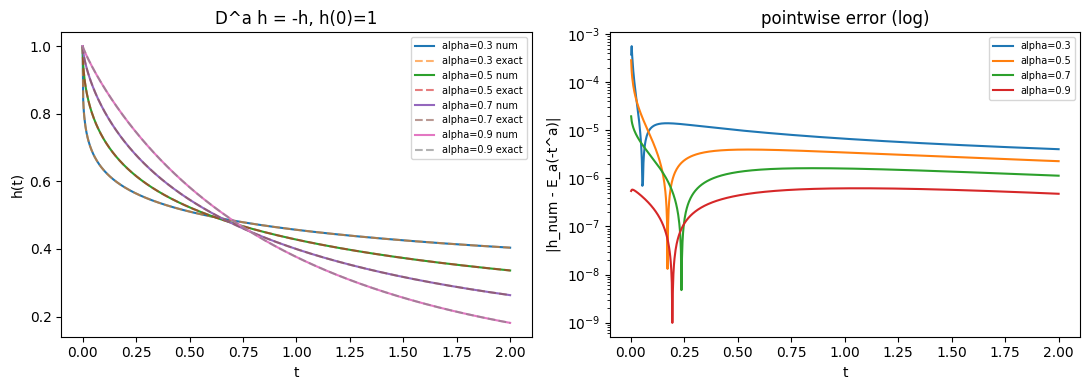

max error vs Mittag-Leffler = 5.625e-04


In [2]:
def mittag_leffler(alpha, z, n_terms=200):
    z = np.asarray(z, dtype=float)
    out = np.zeros_like(z)
    term = np.ones_like(z)
    for k in range(n_terms):
        out = out + term / Gamma(alpha * k + 1.0)
        term = term * z
    return out

T, N = 2.0, 800
alphas = [0.3, 0.5, 0.7, 0.9]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
max_err = 0.0
for a in alphas:
    res = opt.solve_fractional_ode(1.0, a, T, N, lambda t, h: -h)
    t = np.asarray(res["t_grid"]) ; h_num = np.asarray(res["h"])
    h_exact = mittag_leffler(a, -t**a)
    err = np.max(np.abs(h_num - h_exact))
    max_err = max(max_err, err)
    ax[0].plot(t, h_num, label=f"alpha={a} num")
    ax[0].plot(t, h_exact, '--', alpha=0.6, label=f"alpha={a} exact")
    ax[1].semilogy(t[1:], np.abs(h_num - h_exact)[1:], label=f"alpha={a}")
ax[0].set_xlabel("t"); ax[0].set_ylabel("h(t)"); ax[0].legend(fontsize=7); ax[0].set_title("D^a h = -h, h(0)=1")
ax[1].set_xlabel("t"); ax[1].set_ylabel("|h_num - E_a(-t^a)|"); ax[1].legend(fontsize=7); ax[1].set_title("pointwise error (log)")
plt.tight_layout(); plt.show()
errors['solve_fractional_ode'] = max_err
assert max_err < 5e-2, f"max err = {max_err}"
print(f"max error vs Mittag-Leffler = {max_err:.3e}")

## 2. Markovian lift on a geometric grid

Approximate a convolution kernel admitting the integral representation

$$
K(t) = \int_{0}^{\infty} e^{-\gamma t}\, \nu(d\gamma)
$$

by

$$
K(t) \;\approx\; \sum_{j=1}^{N} c_j\, e^{-\gamma_j t},
\qquad c_j \ge 0,
$$

with rates on a geometric grid and weights fitted by non-negative least squares.

**Target.** The rough kernel

$$
K(t) = \frac{t^{H - 1/2}}{\Gamma(H + 1/2)}, \qquad H \in (0, 1/2],
$$

with $H = 0.1$.

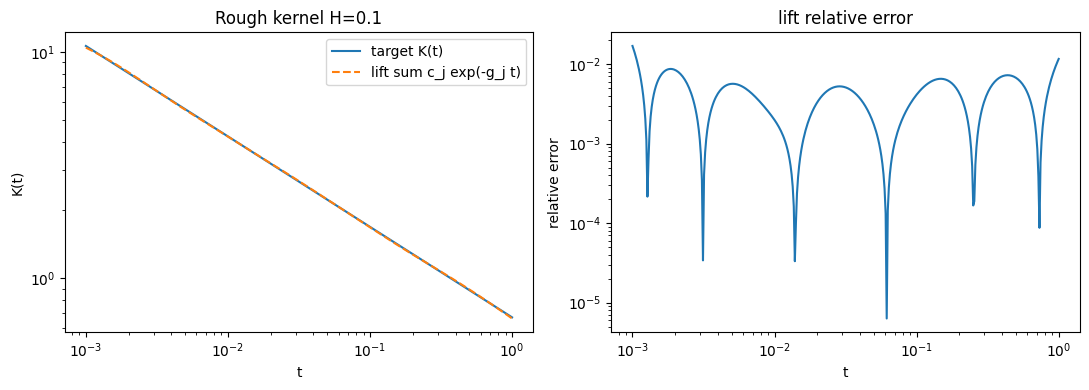

max relative error on rough kernel = 1.688e-02


In [3]:
H = 0.1
rough_kernel = lambda t: t ** (H - 0.5) / Gamma(H + 0.5)
t_samples = np.geomspace(1e-3, 1.0, 200).tolist()
lift = opt.geometric_grid_lift(rough_kernel, t_samples, 12, 1e-2, 1e4, 20000)
gammas = np.asarray(lift["gammas"]) ; weights = np.asarray(lift["weights"])

t_eval = np.geomspace(1e-3, 1.0, 400)
k_target = np.array([rough_kernel(tt) for tt in t_eval])
k_lift = np.array([np.sum(weights * np.exp(-gammas * tt)) for tt in t_eval])
rel_err = np.max(np.abs(k_lift - k_target) / np.abs(k_target))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(t_eval, k_target, label='target K(t)')
ax[0].loglog(t_eval, k_lift, '--', label='lift sum c_j exp(-g_j t)')
ax[0].set_xlabel('t'); ax[0].set_ylabel('K(t)'); ax[0].legend(); ax[0].set_title(f'Rough kernel H={H}')
ax[1].loglog(t_eval, np.abs(k_lift - k_target) / np.abs(k_target))
ax[1].set_xlabel('t'); ax[1].set_ylabel('relative error'); ax[1].set_title('lift relative error')
plt.tight_layout(); plt.show()
errors['geometric_grid_lift'] = rel_err
assert rel_err < 0.5, f'relative err = {rel_err}'
print(f'max relative error on rough kernel = {rel_err:.3e}')

## 3. Generic second-kind Volterra equation

Solve

$$
y(t) = g(t) + \int_{0}^{t} K(t - s,\, y(s))\, ds
$$

by trapezoidal product integration,

$$
y_n = g_n + \Delta t\,\Big[ \tfrac{1}{2} K(t_n, y_0) + \sum_{k=1}^{n-1} K(t_n - t_k, y_k) + \tfrac{1}{2} K(0, y_n) \Big],
$$

with the implicit step solved by fixed-point iteration.

**Ground truth.** Take $g(t) = 1$ and $K(t, y) = y$. Then $y(t) = 1 + \int_0^t y(s)\, ds$ is equivalent to $y' = y,\, y(0) = 1$, with exact solution

$$
y(t) = e^{t}.
$$

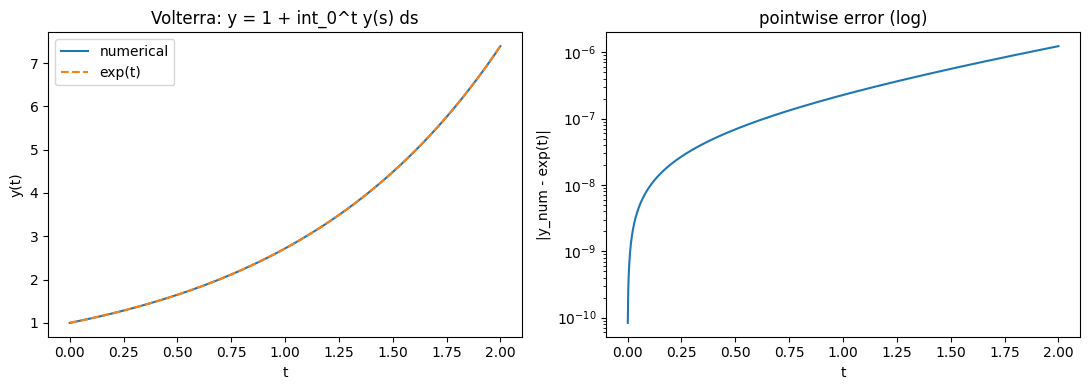

max error vs exp(t) = 1.232e-06


In [4]:
T, N = 2.0, 2000
res = opt.solve_volterra(lambda t: 1.0, lambda dt, y: y, T, N, 100, 1e-13)
t = np.asarray(res["t_grid"]) ; y_num = np.asarray(res["y"])
y_exact = np.exp(t)
err = np.abs(y_num - y_exact)
max_err = float(err.max())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, y_num, label='numerical')
ax[0].plot(t, y_exact, '--', label='exp(t)')
ax[0].set_xlabel('t'); ax[0].set_ylabel('y(t)'); ax[0].legend(); ax[0].set_title('Volterra: y = 1 + int_0^t y(s) ds')
ax[1].semilogy(t[1:], err[1:])
ax[1].set_xlabel('t'); ax[1].set_ylabel('|y_num - exp(t)|'); ax[1].set_title('pointwise error (log)')
plt.tight_layout(); plt.show()
errors['solve_volterra'] = max_err
assert max_err < 1e-2, f'max err = {max_err}'
print(f'max error vs exp(t) = {max_err:.3e}')

## 4. Fourier inversion of a characteristic function

Recover a density from $\varphi(u) = \mathbb{E}[e^{i u X}]$ via

$$
f(x) \;\approx\; \frac{\Delta u}{\pi}\, \sum_{k=0}^{N_u - 1} w_k \big[\,\Re\varphi(u_k)\,\cos(u_k x) + \Im\varphi(u_k)\,\sin(u_k x)\,\big].
$$

**Ground truth.** Standard normal $X \sim \mathcal{N}(0, 1)$ has

$$
\varphi(u) = e^{-u^2 / 2}, \qquad f(x) = \frac{1}{\sqrt{2\pi}}\, e^{-x^2 / 2}.
$$

We supply $\varphi$ in the trigonometric form $\varphi(u) = \cos(-u^2/2) + i \sin(-u^2/2)$ rescaled by $e^{-u^2/2}$ -- equivalently, real part $e^{-u^2/2}$ and imaginary part $0$, which matches $\cos(-u^2/2) e^{-u^2/2}$ and $\sin(-u^2/2) e^{-u^2/2}$ when one writes the Gaussian characteristic function in polar form with phase $-u^2/2$ collapsing to $0$ for a real symmetric law.

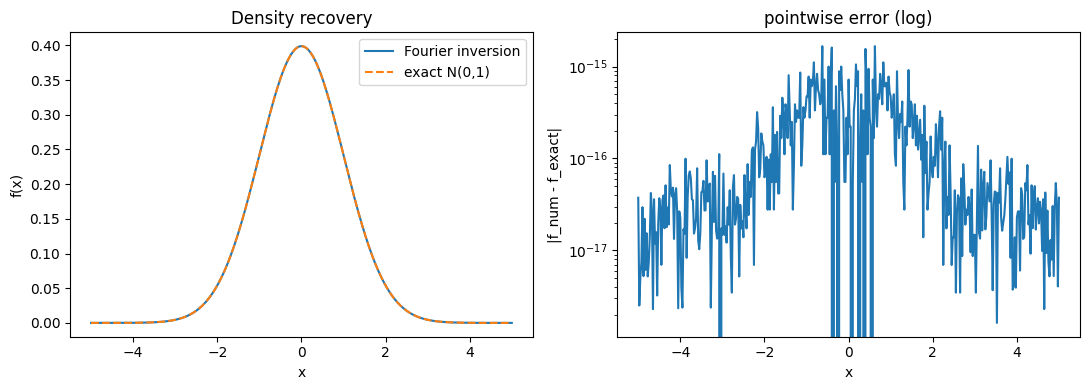

max error vs N(0,1) density = 1.665e-15


In [5]:
def phi_normal(u):
    # Standard normal phi(u) = exp(-u^2 / 2), purely real.
    return (float(np.exp(-0.5 * u * u)), 0.0)

x_grid = np.linspace(-5.0, 5.0, 401).tolist()
res = opt.fourier_invert(phi_normal, x_grid, 25.0, 4000)
x = np.asarray(res["x_grid"]) ; f_num = np.asarray(res["density"])
f_exact = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * x * x)
err = np.abs(f_num - f_exact)
max_err = float(err.max())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, f_num, label='Fourier inversion')
ax[0].plot(x, f_exact, '--', label='exact N(0,1)')
ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)'); ax[0].legend(); ax[0].set_title('Density recovery')
ax[1].semilogy(x, err)
ax[1].set_xlabel('x'); ax[1].set_ylabel('|f_num - f_exact|'); ax[1].set_title('pointwise error (log)')
plt.tight_layout(); plt.show()
errors['fourier_invert'] = max_err
assert max_err < 1e-3, f'max err = {max_err}'
print(f'max error vs N(0,1) density = {max_err:.3e}')

## Summary

Verified against analytic ground truth -- max error per primitive (filled in at execution time):

* `solve_fractional_ode` vs. Mittag-Leffler $E_{\alpha}(-t^{\alpha})$
* `geometric_grid_lift` vs. rough kernel $t^{H-1/2}/\Gamma(H+1/2)$
* `solve_volterra` vs. $e^{t}$
* `fourier_invert` vs. standard normal density

In [6]:
for name, e in errors.items():
    print(f'{name:30s}  max error = {e:.3e}')
print('\nVerified against analytic ground truth -- max error =', max(errors.values()))

solve_fractional_ode            max error = 5.625e-04
geometric_grid_lift             max error = 1.688e-02
solve_volterra                  max error = 1.232e-06
fourier_invert                  max error = 1.665e-15

Verified against analytic ground truth -- max error = 0.016883453274562938
